In [5]:
import torch
import numpy as np
from copy import deepcopy
import pickle as pkl

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from utils_plot import *
from tqdm import tqdm
from utils import *
from functools import reduce
import os
from joblib import Parallel, delayed
import shutil

# http://localhost:8080/tree?token=98ea3fcb0b09366b2803c421736080a9ed9f4ca179479adf

In [6]:
# import pandas as pd
# df_hyper = pd.read_pickle("figures/scan_MNIST/results_summary.df")
# df_hyper.sort_values(by='r2', ascending=False, inplace=True)
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6,4))
# plt.scatter(df_hyper['mse_loss'], df_hyper['r2'], alpha=0.7)
# plt.xlabel('MSE Loss')
# plt.ylabel('R2')
# plt.title('Scatter of MSE Loss vs R2')
# plt.grid(True)
# plt.show()

In [7]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [8]:
C = Config()
C.G = 0.9
C.sig_h_2 = None
C.linear_net = True
C.learning_rate = 0.1
C.L=2
C.print_progress = True
C.length_corridors = [10]*1
C.max_move = 3
C.hidden_size = 50 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 10000
C.algo_name = 'SGD'
C.loss_fn = nn.CrossEntropyLoss()

# C.min_move = 2
# C.one_hot_actions = True
# C.one_hot_inputs = False
# var_name = 'G'
# var_values = [0.1, 1, 10]
# var_name = 'action_list'
# var_values = [[-A,-1,0,1,A] for A in range(2, C.length_corridors[0])]
var_name = 'L'
var_values = np.arange(0, 10).astype(int) # [1, C.length_corridors[0]//4, C.length_corridors[0]//2, 3*C.length_corridors[0]//4, C.length_corridors[0]-1] # np.arange(C.length_corridors[0]) #  
# var_name = 'L'
# var_values = [9, 10]
# var_values = np.arange(6, 16)

In [9]:
num_gpus = 4

# Ensure the results directory exists
results_dir = f'results/notebook_results/circular/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value, index):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    if var_name == 'L':
        C_local.learning_rate = C.learning_rate * 0.6**C_local.L if C_local.L > 0 else 1
    C_local.gpu_id = index % num_gpus + 4
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    # Remove 'state_dict_l' and 'hidden_l' from data_dict if they exist
    data_dict.pop('state_dict_l', None)
    data_dict.pop('hidden_l', None)
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value, index) for index, var_value in enumerate(var_values)
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7

Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7

Variance of last hidden: 1.06e+00, of output: 1.76e+00
Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7

Variance of last hidden: 5.51e+00, of output: 9.41e+00
Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7

Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7

Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7

Variance of last hidden: 5.84e-01, of output: 1.14e+00
Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7

Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7



  0%|          | 15/10000 [00:00<05:06, 32.54it/s]s]

Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7

Number of samples: 58
Input dimension: 17
Output dimension: 10
Number of actions: 7



  1%|          | 82/10000 [00:01<02:36, 63.38it/s]] 

Variance of last hidden: 2.36e+00, of output: 3.17e+00


...

Variance of last hidden: 1.53e-01, of output: 2.40e-01


  0%|          | 1/10000 [00:00<47:33,  3.50it/s]/s]

Variance of last hidden: 9.73e-02, of output: 1.71e-01
Variance of last hidden: 2.14e-01, of output: 4.41e-01


100%|██████████| 10000/10000 [02:32<00:00, 65.69it/s]


L: 0 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 1 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 2 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 3 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 4 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 5 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 6 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 7 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 8 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50
L: 9 --- X shape: torch.Size([58, 17]) --- Number of hidden: 50


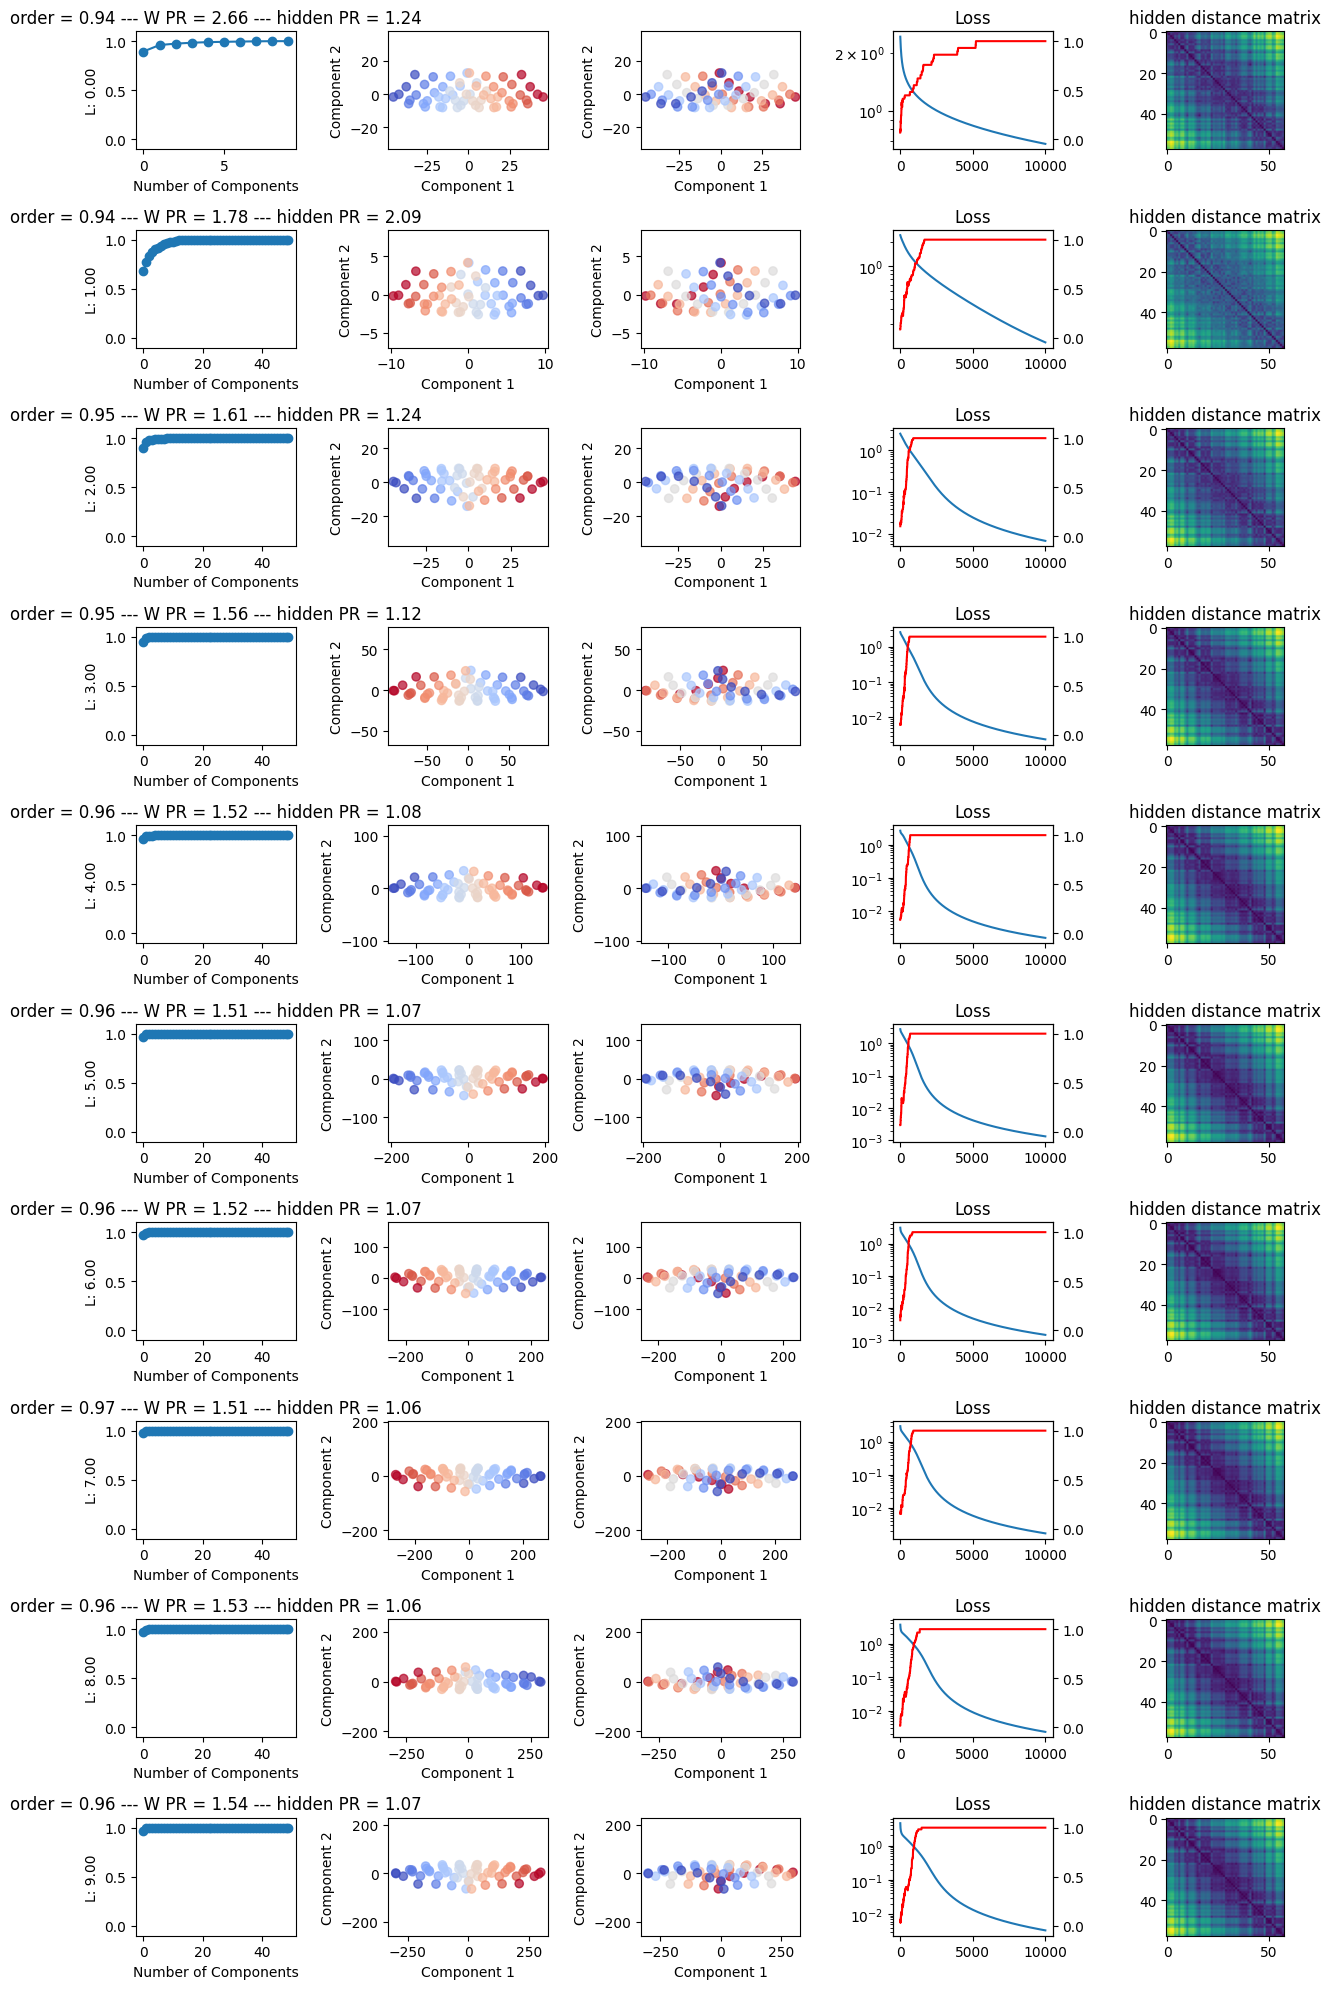

In [10]:
from utils_plot import plot_pca
fig, axs = plt.subplots(len(data_dict_l), 5, figsize=(25/2, len(data_dict_l)*4/2))
for data_dict, axs_current in zip(data_dict_l, axs):
    plot_pca(data_dict, axs=axs_current, action_filter=100)
    axs_current[0].set_ylabel(f'{var_name}: {getattr(data_dict["C"], var_name):.2f}')
fig.savefig(r'.\wide.png', dpi=300, bbox_inches='tight')

In [11]:

def schatten_2_over_L(A, L):
    """Schatten-(2/L) norm of matrix A."""
    if L == 0:
        return np.linalg.norm(A, ord='fro')
    p = 2.0 / L
    s = np.linalg.svd(A, compute_uv=False)
    return np.sum(s ** p) ** (1.0 / p)


def geometric_multiclass_margins(W, X, y):
    """
    For each sample, find the hardest class pair and return the signed
    distance from x to the decision hyperplane (w_true - w_other)^T x = 0.
    """
    if y.ndim > 1:
        labels = y.argmax(axis=1)
    else:
        labels = y
    X = np.asarray(X, dtype=float)
    W = np.asarray(W, dtype=float)
    n_samples, n_classes = X.shape[0], W.shape[1]
    margins = np.empty(n_samples, dtype=float)
    for i in range(n_samples):
        x = X[i]
        y_i = labels[i]
        best = np.inf
        for k in range(n_classes):
            if k == y_i:
                continue
            w_diff = W[:, y_i] - W[:, k]
            norm_diff = np.linalg.norm(w_diff)
            if norm_diff == 0:
                continue
            geom = (w_diff @ x) / norm_diff
            if geom < best:
                best = geom
        margins[i] = best
    return margins


def min_multiclass_margin(W, X, y, normalization='geometric', L=None):
    """
    Smallest multiclass margin under one of three normalizations:
      'geometric' - distance to hardest decision plane (unnormalized W)
      'l2'        - functional margin with W / ||W||_F
      'schatten'  - functional margin with W / ||W||_{2/L}
    """
    W = np.asarray(W, dtype=float)
    if normalization == 'geometric':
        return np.min(geometric_multiclass_margins(W, X, y))
    if normalization == 'l2':
        W = W / np.linalg.norm(W)
    elif normalization == 'schatten':
        if L is None:
            raise ValueError("L is required for schatten normalization")
        W = W / schatten_2_over_L(W, L)
    else:
        raise ValueError(f"Unknown normalization: {normalization}")
    return multiclass_functional_margin(W, X, y, reducer=np.min, normalize=False)[0]


def min_multiclass_margin_from_data_dict(data_dict, normalization='geometric'):
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    L = data_dict['C'].L
    return min_multiclass_margin(W, X, y, normalization=normalization, L=L)


,L,accuracy,min_geometric_margin,min_l2_margin,min_schatten_margin
0,0,1.0,0.015198,0.002100,0.002100
1,1,1.0,0.019632,0.005654,0.005654
2,2,1.0,0.015682,0.006290,0.004954
3,3,1.0,0.036840,0.005798,0.002853
4,4,1.0,0.038461,0.005352,0.001356
5,5,1.0,0.041091,0.005228,0.000574
6,6,1.0,0.037228,0.005082,0.000221
7,7,1.0,0.032484,0.005044,0.000082
8,8,1.0,0.038164,0.005234,0.000028
9,9,1.0,0.033385,0.005014,0.000009


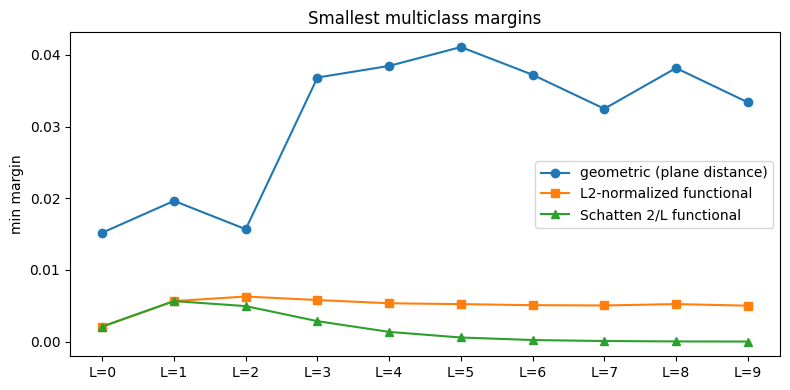

In [12]:
# comparing margins of all networks
import pandas as pd

margin_rows = []
for data_dict in data_dict_l:
    C = data_dict['C']
    W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    labels = y.argmax(axis=1)

    margin_rows.append({
        var_name: getattr(C, var_name),
        'accuracy': ((X @ W).argmax(1) == labels).mean(),
        'min_geometric_margin': min_multiclass_margin(W, X, y, normalization='geometric'),
        'min_l2_margin': min_multiclass_margin(W, X, y, normalization='l2'),
        'min_schatten_margin': min_multiclass_margin(W, X, y, normalization='schatten', L=C.L),
    })

df_margins = pd.DataFrame(margin_rows)
display(df_margins)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_margins))

ax.plot(x, df_margins['min_geometric_margin'], marker='o', label='geometric (plane distance)')
ax.plot(x, df_margins['min_l2_margin'], marker='s', label='L2-normalized functional')
ax.plot(x, df_margins['min_schatten_margin'], marker='^', label='Schatten 2/L functional')

ax.set_xticks(x)
ax.set_xticklabels([f'{var_name}={v}' for v in df_margins[var_name]])
ax.set_ylabel('min margin')
ax.set_title('Smallest multiclass margins')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
data_dict = data_dict_l[3]
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelBinarizer

X = data_dict['X'].cpu().numpy()
y = data_dict['y'].cpu().numpy()
W = get_effective_W_from_model_dict(data_dict['final_weights']).cpu().numpy()
labels = y.argmax(axis=1)

from sklearn.svm import LinearSVC

# Use a large C to approximate the hard-margin/max-margin linear SVM
clf = LinearSVC(C=1e8, multi_class='crammer_singer', fit_intercept=False, dual=False, max_iter=100000, tol=1e-16)
clf.fit(X, labels)

# Print accuracy
accuracy = clf.score(X, labels)
print("SVM accuracy:", accuracy)

# Compute margins for each sample (decision_function gives raw scores)
# For multiclass: margin = f_y(x) - max_{k≠y} f_k(x)
decision_scores = clf.decision_function(X)
true_scores = decision_scores[np.arange(len(labels)), labels]
decision_scores_masked = np.copy(decision_scores)
decision_scores_masked[np.arange(len(labels)), labels] = -np.inf
max_other_scores = decision_scores_masked.max(axis=1)
margins = true_scores - max_other_scores

print("SVM min margin:", margins.min())
print("SVM mean margin:", margins.mean())
print("SVM margins (first 5 samples):", margins[:5])

# Print final weight matrix
W_SVM = clf.coef_.T
print("SVM weight matrix shape:", W_SVM.shape)

SVM accuracy: 1.0
SVM min margin: 0.9999999928742369
SVM mean margin: 0.999999998857264
SVM margins (first 5 samples): [1. 1. 1. 1. 1.]
SVM weight matrix shape: (17, 10)


/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [14]:
SVM_margins = min_multiclass_margin(W_SVM, X, y, normalization='l2')
W_margins = min_multiclass_margin(W, X, y, normalization='l2')

print("SVM min margin:", SVM_margins.min())
print("SVM mean margin:", SVM_margins.mean())

print("W min margin:", W_margins.min())
print("W mean margin:", W_margins.mean())

SVM min margin: 0.006874983006277854
SVM mean margin: 0.006874983006277854
W min margin: 0.00579845708530452
W mean margin: 0.00579845708530452


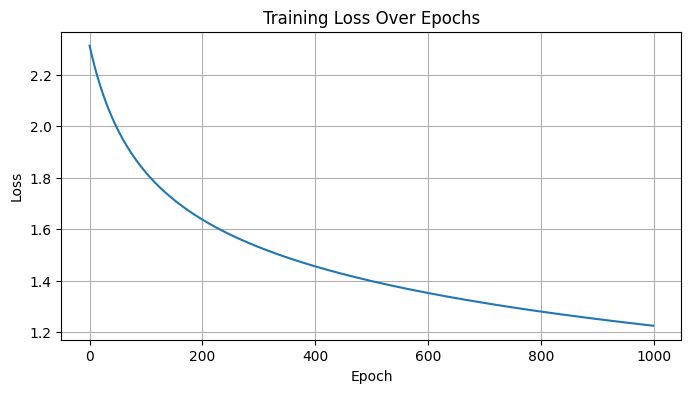

Linear classifier accuracy: 0.5517241358757019
Linear classifier min margin: -0.17017674
Linear classifier mean margin: 0.16373028
Linear classifier margins (first 5 samples): [0.6089556  0.47307134 0.3869393  1.144966   0.5814605 ]


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

data_dict = data_dict_l[0]
X = data_dict['X'].cpu().numpy()
y = data_dict['y'].cpu().numpy()
labels = y.argmax(axis=1)

# Use torch tensors for training
X_tensor = torch.tensor(X, dtype=torch.float32)
y_labels = torch.tensor(labels, dtype=torch.long)
n_classes = len(np.unique(labels))
n_features = X.shape[1]

# Define a single-matrix linear classifier (no bias)
linear = nn.Linear(n_features, n_classes, bias=False)
# Initialize weights similar to sklearn's SVM
# nn.init.xavier_normal_(linear.weight)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(linear.parameters(), lr=1)

n_epochs = 1000
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    outputs = linear(X_tensor)
    loss = criterion(outputs, y_labels)
    # losses.append(loss.item())
    loss.backward()
    optimizer.step()

# Plot loss throughout training
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Accuracy
with torch.no_grad():
    logits = linear(X_tensor)
    preds = torch.argmax(logits, dim=1)
    accuracy = (preds == y_labels).float().mean().item()

    # Calculate margins for each sample (like SVM/Crammer-Singer)
    logits_np = logits.numpy()
    true_class_scores = logits_np[np.arange(len(labels)), labels]
    logits_masked = np.copy(logits_np)
    logits_masked[np.arange(len(labels)), labels] = -np.inf
    max_other_scores = logits_masked.max(axis=1)
    margins = true_class_scores - max_other_scores

print("Linear classifier accuracy:", accuracy)
print("Linear classifier min margin:", margins.min())
print("Linear classifier mean margin:", margins.mean())
print("Linear classifier margins (first 5 samples):", margins[:5])

In [19]:
print(next(linear.parameters()).device, X_tensor.device)


cpu cpu
